**BEUST Léna**

_______________
# **Startup Name Generator**

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf

2026-05-09 10:10:57.764834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 10:10:57.860843: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 10:10:57.861196: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 10:10:58.000887: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 10:10:59.207323: W tensorflow/compiler/tf

In [2]:
keras = tf.keras

with open("companies.csv") as corpus_file:
    corpus = corpus_file.read()
    corpus_length = len(corpus)
print("Loaded a corpus of {0} characters".format(corpus_length))

Loaded a corpus of 2567986 characters


In [3]:
chars = sorted(list(set(corpus)))
num_chars = len(chars)
encoding = {c: i for i, c in enumerate(chars)}
decoding = {i: c for i, c in enumerate(chars)}
print("Our corpus contains {0} unique characters.".format(num_chars))
print(chars[:20], "...")

Our corpus contains 150 unique characters.
['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2'] ...


In [4]:
print(encoding)
print(decoding)

{'\n': 0, ' ': 1, '!': 2, '"': 3, '#': 4, '$': 5, '%': 6, '&': 7, "'": 8, '(': 9, ')': 10, '*': 11, '+': 12, ',': 13, '-': 14, '.': 15, '/': 16, '0': 17, '1': 18, '2': 19, '3': 20, '4': 21, '5': 22, '6': 23, '7': 24, '8': 25, '9': 26, ':': 27, '=': 28, '>': 29, '?': 30, '@': 31, 'A': 32, 'B': 33, 'C': 34, 'D': 35, 'E': 36, 'F': 37, 'G': 38, 'H': 39, 'I': 40, 'J': 41, 'K': 42, 'L': 43, 'M': 44, 'N': 45, 'O': 46, 'P': 47, 'Q': 48, 'R': 49, 'S': 50, 'T': 51, 'U': 52, 'V': 53, 'W': 54, 'X': 55, 'Y': 56, 'Z': 57, '[': 58, '\\': 59, ']': 60, '^': 61, '_': 62, 'a': 63, 'b': 64, 'c': 65, 'd': 66, 'e': 67, 'f': 68, 'g': 69, 'h': 70, 'i': 71, 'j': 72, 'k': 73, 'l': 74, 'm': 75, 'n': 76, 'o': 77, 'p': 78, 'q': 79, 'r': 80, 's': 81, 't': 82, 'u': 83, 'v': 84, 'w': 85, 'x': 86, 'y': 87, 'z': 88, '{': 89, '|': 90, '}': 91, '~': 92, '\x81': 93, '\x82': 94, '\x83': 95, '\x84': 96, '\x85': 97, '\x86': 98, '\x87': 99, '\x88': 100, '\x89': 101, '\x8a': 102, '\x8b': 103, '\x8c': 104, '\x8d': 105, '\x8e': 

## **Many-to-one approach**

In [6]:
sentence_length = 10  # the length of the sequence at RNN input
skip = 3              # overlap
X_data = []
y_data = []
for i in range (0, len(corpus) - sentence_length, skip):
    sentence = corpus[i:i + sentence_length]
    next_char = corpus[i + sentence_length]
    X_data.append([encoding[char] for char in sentence])
    y_data.append(encoding[next_char])

num_sentences = len(X_data)
print("Sliced our corpus into {0} sentences of length {1}"
      .format(num_sentences, sentence_length))

Sliced our corpus into 855992 sentences of length 10


In [7]:
print('Encoded data[0]          : {}'.format(X_data[0]))
print('Target of data[0]        : {}'.format(y_data[0]))
print('Decoded data[0]          : {}'.format([decoding[idx] for idx in X_data[0]]))
print('Decoded Target of data[0]: {}'.format(decoding[y_data[0]]))

Encoded data[0]          : [39, 63, 81, 70, 78, 74, 63, 87, 1, 40]
Target of data[0]        : 76
Decoded data[0]          : ['H', 'a', 's', 'h', 'p', 'l', 'a', 'y', ' ', 'I']
Decoded Target of data[0]: n


In [8]:
# Vectorize our data and labels. We want everything in one-hot.
X = np.zeros((num_sentences, sentence_length, num_chars), dtype=bool)   # many input
y = np.zeros((num_sentences, num_chars), dtype=bool)    # one output
for i, sentence in enumerate(X_data):
    for t, encoded_char in enumerate(sentence):
        X[i, t, encoded_char] = 1
    y[i, y_data[i]] = 1

# Double check our vectorized data before we sink hours into fitting a model
print("Sanity check y. Dimension: {0} # Sentences: {1} Characters in corpus: {2}"
      .format(y.shape, num_sentences, len(chars)))
print("Sanity check X. Dimension: {0} Sentence length: {1}"
      .format(X.shape, sentence_length))

Sanity check y. Dimension: (855992, 150) # Sentences: 855992 Characters in corpus: 150
Sanity check X. Dimension: (855992, 10, 150) Sentence length: 10


In [9]:
# Define our model
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(sentence_length, num_chars)))
model.add(keras.layers.SimpleRNN(64, return_sequences=False))   # one to many : RNN oly return the outpu of the last time stap, not one outpu per step
model.add(keras.layers.Dense(num_chars))
model.add(keras.layers.Activation('softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])
model.summary()

2026-05-09 10:12:53.134402: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 10:12:53.595029: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        13,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │         9,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,510 (91.84 KB)

 Trainable params: 23,510 (91.84 KB)

 Non-trainable params: 0 (0.00 B)

2026-05-09 10:13:00.946912: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1283988000 exceeds 10% of free system memory.
2026-05-09 10:13:01.662294: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 128398800 exceeds 10% of free system memory.


Epoch 1/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.2772 - loss: 2.6048
Epoch 2/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.3471 - loss: 2.3098
Epoch 3/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.3651 - loss: 2.2398
Epoch 4/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.3756 - loss: 2.2011
Epoch 5/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.3826 - loss: 2.1750
Epoch 6/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.3880 - loss: 2.1555
Epoch 7/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.3920 - loss: 2.1411
Epoch 8/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.3948 - loss: 2.1288
Epoch 9/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.3982 - loss: 2.1192
Epoch 10/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.3995 - loss: 2.1118


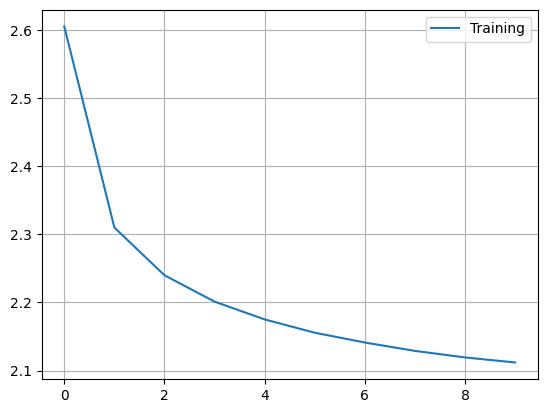

In [10]:
log = model.fit(X, y, epochs=10, batch_size=128)
plt.plot(log.history['loss'], label='Training')
plt.legend()
plt.grid()

In [14]:
def make_seed(seed_phrase=""):
        if seed_phrase:  # make sure the seed has the right length
            phrase_length = len(seed_phrase)
            pattern = ""
            for i in range (0, sentence_length):
                pattern += seed_phrase[i % phrase_length]
        else:            # sample randomly the seed from corpus
            seed = random.randint(0, corpus_length - sentence_length)
            pattern = corpus[seed:seed + sentence_length]
        return pattern

seed_pattern = make_seed("My startup name is ")
print("seed = " + seed_pattern)

X = np.zeros((1, sentence_length, num_chars), dtype=float)
for i, character in enumerate(seed_pattern):
    X[0, i, encoding[character]] = 1

generated_text = ""
for i in range(500):
    output_prob = model.predict(X, verbose=0)[0]
    prediction = np.random.choice(num_chars, p = output_prob )
    generated_text += decoding[prediction]
    activations = np.zeros((1, 1, num_chars), dtype=bool)
    activations[0, 0, prediction] = 1
    X = np.concatenate((X[:, 1:, :], activations), axis=1) #now remove first char and glue the predicted one
print(generated_text)

seed = My startup

Grands Pood
Cure
ParracaSups
Fissesscing
7.com
Kinsoin Markeer
Elenta
Smartio
Yavix
Vinn ValumExcraren
Valda Healthcarity by Powro EVG
Mod enari, Ansimal do Solution Group
Zubborrs
Detun Ex
HartShashSmact
Argal Ang
SERU
Fruga Wythess
Wialliak
CanAvero.com
ChStert
Lamber Vieshcho
Cyburv
GOTANT
Fisticm
IQ DiMet Monilal Manker Partning Call Banios
ARSOUSI Finances Powter Games
"TaRFyss Lishocital Purna
Lyt-Fo
Bliplec Workt Arpertics
Reldso
Dolaking Beerti Group
armak Hofting Group"
NortFix
BlaRES



## **Many to many approach**

In [15]:
sentence_length = 10
skip = 3
X_data = []
y_data = []
for i in range (0, len(corpus) - sentence_length, skip):
    sentence = corpus[i:i + sentence_length]
    next_chars = corpus[i+1:i+1 + sentence_length]  # this is different from before, 
    # we want to predict the next char at each time step, not just the next char after the whole sentence
    X_data.append([encoding[char] for char in sentence])
    y_data.append([encoding[char] for char in next_chars])

num_sentences = len(X_data)
print("Sliced our corpus into {0} sentences of length {1}"
      .format(num_sentences, sentence_length))

Sliced our corpus into 855992 sentences of length 10


In [16]:
print(X_data[0])

[39, 63, 81, 70, 78, 74, 63, 87, 1, 40]


In [17]:
print([decoding[idx] for idx in X_data[0]])
print([decoding[idx] for idx in y_data[0]])

['H', 'a', 's', 'h', 'p', 'l', 'a', 'y', ' ', 'I']
['a', 's', 'h', 'p', 'l', 'a', 'y', ' ', 'I', 'n']


In [ ]:
X = np.zeros((num_sentences, sentence_length, num_chars), dtype=bool)   # many inputs
y = np.zeros((num_sentences, sentence_length, num_chars), dtype=bool)   # many ouputs
for i, sentence in enumerate(X_data):
    for t, encoded_char in enumerate(sentence):
        X[i, t, encoded_char] = 1
for i, sentence in enumerate(y_data):
    for t, encoded_char in enumerate(sentence):
        y[i, t, encoded_char] = 1

In [19]:
modelmm = keras.models.Sequential()
modelmm.add(keras.layers.Input(shape=(sentence_length, num_chars)))
modelmm.add(keras.layers.SimpleRNN(64, return_sequences=True)) 
# return_sequences=True because we want to predict the next char at each time step, not just the next char after the whole sentence
modelmm.add(keras.layers.TimeDistributed(keras.layers.Dense(num_chars,
                                                          activation='softmax')))
modelmm.compile(loss='categorical_crossentropy', optimizer='adam', 
              metrics=['accuracy'])
modelmm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 64)         │        13,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 150)        │         9,750 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,510 (91.84 KB)

 Trainable params: 23,510 (91.84 KB)

 Non-trainable params: 0 (0.00 B)

2026-05-09 10:18:43.846217: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1283988000 exceeds 10% of free system memory.


Epoch 1/10


2026-05-09 10:18:46.660610: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1283988000 exceeds 10% of free system memory.


6688/6688 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - accuracy: 0.2891 - loss: 2.5389
Epoch 2/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - accuracy: 0.3421 - loss: 2.3139
Epoch 3/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.3532 - loss: 2.2720
Epoch 4/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.3592 - loss: 2.2508
Epoch 5/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.3631 - loss: 2.2374
Epoch 6/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3654 - loss: 2.2283
Epoch 7/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.3671 - loss: 2.2219
Epoch 8/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.3682 - loss: 2.2170
Epoch 9/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.3690 - loss: 2.2133
Epoch 10/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 54s 8ms/step - accuracy: 0.3696 - loss: 2.2104


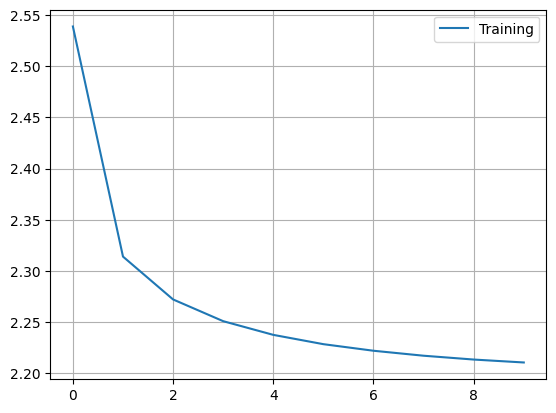

In [20]:
log = modelmm.fit(X, y, epochs=10, batch_size=128)
plt.plot(log.history['loss'], label='Training')
plt.legend()
plt.grid()

In [21]:
def make_seed(seed_phrase=""):
        if seed_phrase: 
            phrase_length = len(seed_phrase)
            pattern = ""
            for i in range (0, sentence_length):
                pattern += seed_phrase[i % phrase_length]
        else:            # sample randomly the seed from corpus
            seed = random.randint(0, corpus_length - sentence_length)
            pattern = corpus[seed:seed + sentence_length]
        return pattern

seed_pattern = make_seed("My startup name is")

X = np.zeros((1, sentence_length, num_chars), dtype=float)
for i, character in enumerate(seed_pattern):
    X[0, i, encoding[character]] = 1

generated_text = ""
for i in range(500):
    output_prob = modelmm.predict(X, verbose=0)[0][-1] # with 1 being the size of the batch, for that we use [0][-1] 
    prediction = np.random.choice(num_chars, p = output_prob )
    generated_text += decoding[prediction]
    activations = np.zeros((1, 1, num_chars), dtype=bool)
    activations[0, 0, prediction] = 1
    X = np.concatenate((X[:, 1:, :], activations), axis=1)
print(generated_text)


Pirmiasy Group
Cenica WireXCisate Monluctions
LivP
Twikqeen
Dhean
Cleal Morki
Ridversure Sometrouy
CJT Italieg Ltd."
comnjing Designment Payence
GLo fff Sistic
Otienos Ltd.
TradecaltCurmenticr Frectio
Salocate Incomicans
Neworpers
nsMax UOSI & Stacroop
CR&G Industry
Tift
Captwide Sodurite Desal
Techam Inc.
Greenyy Servical Pablish Dynowe.com
DA'MiveCrayeja Falserbleo, Inc."
Goldy: Solutions
Skavobier Construmsse Augetcck
Plack Spine
Poomondix Glopicolital SupCass
Herformen Kenolumicon Makrii Av


# **One-to-many approach**

In [22]:
sentence_length = 10  # how many character to predict
skip = 3              # overlap
X_data = []
y_data = []
for i in range (0, len(corpus) - sentence_length - 1, skip):
    seed = corpus[i]                                 # one single input char
    next_chars = corpus[i + 1 : i + 1 + sentence_length]  # next chars to predict
    X_data.append([encoding[seed]])
    y_data.append([encoding[c] for c in next_chars])

num_sentences = len(X_data)

In [ ]:
X = np.zeros((num_sentences, 1, num_chars), dtype=bool)                 # one hot one time
y = np.zeros((num_sentences, sentence_length, num_chars), dtype=bool)   # sequence of one hot
for i in range(num_sentences):
    X[i, 0, X_data[i]] = 1
    for t, enc in enumerate(y_data[i]):
        y[i, t, enc] = 1


In [28]:
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(1, num_chars)))             # one to many
model.add(keras.layers.SimpleRNN(64, return_sequences=False))  # False → outputs (batch, 64)
model.add(keras.layers.RepeatVector(sentence_length))           # needs 2D input
model.add(keras.layers.SimpleRNN(64, return_sequences=True))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(num_chars, activation='softmax')))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        13,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 10, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 150)        │         9,750 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,766 (124.09 KB)

 Trainable params: 31,766 (124.09 KB)

 Non-trainable params: 0 (0.00 B)

2026-05-09 10:40:07.629306: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 128398800 exceeds 10% of free system memory.


Epoch 1/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.0970 - loss: 3.4147
Epoch 2/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.1028 - loss: 3.3786
Epoch 3/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.1042 - loss: 3.3732
Epoch 4/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.1046 - loss: 3.3703
Epoch 5/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.1054 - loss: 3.3682
Epoch 6/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.1060 - loss: 3.3667
Epoch 7/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.1063 - loss: 3.3657
Epoch 8/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.1064 - loss: 3.3649
Epoch 9/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - accuracy: 0.1065 - loss: 3.3644
Epoch 10/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - accuracy: 0.1066 - loss: 3.3639


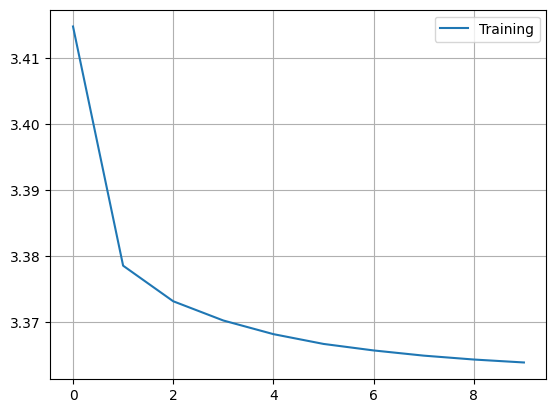

In [29]:
log = model.fit(X, y, epochs=10, batch_size=128)
plt.plot(log.history['loss'], label='Training')
plt.legend()
plt.grid()

In [34]:
def generate_from_char(seed_char, n_sequences=5):
    x_seed = np.zeros((1, 1, num_chars), dtype=float)
    x_seed[0, 0, encoding[seed_char]] = 1

    probs = model.predict(x_seed, verbose=0)[0]  # shape: (target_length, num_chars)

    results = []
    for _ in range(n_sequences):
        generated = ""
        for step_probs in probs:
            predicted_idx = np.random.choice(num_chars, p=step_probs)
            generated += decoding[predicted_idx]
        results.append(generated)
    return results

# Pick a random seed character from the corpus
seed_char = random.choice(corpus)
print(f"Seed character: '{seed_char}'")

for i, seq in enumerate(generate_from_char(seed_char, n_sequences=5), 1):
    print(f"  [{i}] {seq}")

Seed character: ' '
  [1] Palip
Goge
  [2] Vol crCosr
  [3] Iedpi aais
  [4] Sethonoieo
  [5] GoHanoi ls


# **With LSTM**

In [35]:
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(1, num_chars)))             # one to many
model.add(keras.layers.LSTM(64, return_sequences=False))  # False → outputs (batch, 64)
model.add(keras.layers.RepeatVector(sentence_length))           # needs 2D input
model.add(keras.layers.LSTM(64, return_sequences=True))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(num_chars, activation='softmax')))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        55,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 150)        │         9,750 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,814 (382.09 KB)

 Trainable params: 97,814 (382.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - accuracy: 0.0928 - loss: 3.4366
Epoch 2/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - accuracy: 0.1040 - loss: 3.3769
Epoch 3/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - accuracy: 0.1067 - loss: 3.3665
Epoch 4/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - accuracy: 0.1075 - loss: 3.3623
Epoch 5/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.1079 - loss: 3.3600
Epoch 6/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - accuracy: 0.1083 - loss: 3.3586
Epoch 7/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - accuracy: 0.1085 - loss: 3.3576
Epoch 8/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 58s 9ms/step - accuracy: 0.1086 - loss: 3.3568
Epoch 9/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - accuracy: 0.1086 - loss: 3.3562
Epoch 10/10
6688/6688 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - accuracy: 0.1088 - loss: 3.3557


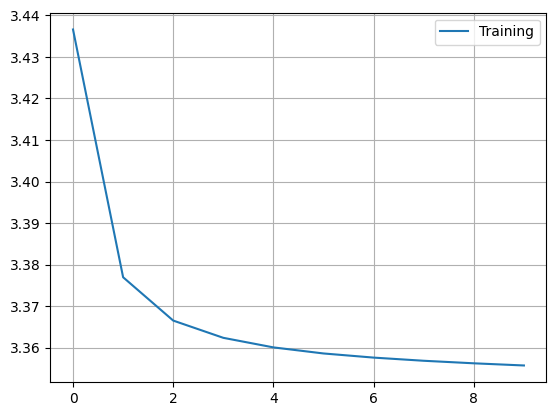

In [36]:
log = model.fit(X, y, epochs=10, batch_size=128)
plt.plot(log.history['loss'], label='Training')
plt.legend()
plt.grid()

In [40]:
seed_char = random.choice(corpus)
print(f"Seed character: '{seed_char}'")

for i, seq in enumerate(generate_from_char(seed_char, n_sequences=5), 1):
    print(f"  [{i}] {seq}")

Seed character: 'e'
  [1] dnBScS tns
  [2] 
gCtGDDgpd
  [3] rAPl saeli
  [4] lEsy  lgte
  [5] ttrtdizslt


- Can we reduce further the loss ?
by adding more layers and/or increase number of hidden units.

- Do you observe improvements in the quality of generated names ?
not really...